# The Correlation Between Survival Rates in Himalayan Mountain Expeditions and Climbers' Economic Backgrounds
**Student Name:** Elif Çamlıkaya  
**ID:** 35191

## Milestone 2: Machine Learning — Classification

In Milestone 1 I confirmed through statistical tests that:
- **GDP per capita** significantly affects survival (t-test, p < 0.00001)
- **Gender** is significantly correlated with survival (chi-square, p = 0.00011)

In Milestone 2 I build a **Random Forest Classifier** to *predict* survival. Beyond the original three demographic features, I enriched the model with physical climbing variables:
- **Oxygen Use** — Did the climber use supplemental oxygen?
- **Season** — Was it the safer Spring or the deadly Winter?
- **Peak Height** — Is the target an 8,000m giant or a smaller mountain?





| File | Purpose |
|---|---|
| `members.csv` | Climber demographics & survival data |
| `API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv` | World Bank GDP data |
| `peaks.csv` | Mountain height data |
| `expeditions.csv` | (uploaded but not used — keeping for completeness) |


In [5]:
from google.colab import files

print("⬆️  A file picker will appear below. Select ALL your CSV files and click Open.")
uploaded = files.upload()
print("\n✅ Files uploaded successfully!")
for fname in uploaded.keys():
    print(f"   • {fname}")

⬆️  A file picker will appear below. Select ALL your CSV files and click Open.


Saving API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv to API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46 (2).csv
Saving expeditions.csv to expeditions (2).csv
Saving members.csv to members (2).csv
Saving Metadata_Country_API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv to Metadata_Country_API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46 (2).csv
Saving peaks.csv to peaks (2).csv

✅ Files uploaded successfully!
   • API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46 (2).csv
   • expeditions (2).csv
   • members (2).csv
   • Metadata_Country_API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46 (2).csv
   • peaks (2).csv


## Step 1 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

sns.set_theme(context='talk', style='whitegrid', palette='colorblind')
print("✅ All libraries imported.")

✅ All libraries imported.


## Step 2 — Load and Merge All Datasets

We can build one big Data Frame by merging three data sources:
1. **`members.csv`** — our base table with one row per climber
2. **GDP data** — joined on `citizenship` + `year` to add national wealth
3. **`peaks.csv`** — joined on `peak_id` to add mountain height

In [7]:
#  Load files from uploaded dict:
import io

members_df = pd.read_csv(io.BytesIO(uploaded['members (2).csv']))
peaks_df   = pd.read_csv(io.BytesIO(uploaded['peaks (2).csv']))

# Detecting the GDP filename (works regardless of exact filename)
gdp_filename = None
for name in uploaded.keys():
    if 'GDP' in name.upper() and 'METADATA' not in name.upper():
        gdp_filename = name
        break

if gdp_filename is None:
    raise FileNotFoundError("Could not find the GDP CSV. Make sure you uploaded it.")

gdp_df = pd.read_csv(io.BytesIO(uploaded[gdp_filename]), skiprows=4)
print(f"Loaded GDP file: '{gdp_filename}'")

# Reshaping GDP from wide to long format:
cols_to_drop = ['Country Code', 'Indicator Name', 'Indicator Code']
cols_to_drop += [c for c in gdp_df.columns if c.startswith('Unnamed')]
gdp_df = gdp_df.drop(columns=[c for c in cols_to_drop if c in gdp_df.columns])

gdp_long = pd.melt(gdp_df, id_vars=['Country Name'],
                   var_name='year', value_name='gdp_per_capita')
gdp_long['year'] = pd.to_numeric(gdp_long['year'], errors='coerce')
gdp_long = gdp_long.dropna(subset=['year'])
gdp_long['year'] = gdp_long['year'].astype(int)

# Merging members + GDP + peak height:
df = pd.merge(members_df, gdp_long,
              left_on=['citizenship', 'year'],
              right_on=['Country Name', 'year'],
              how='left')

df = pd.merge(df, peaks_df[['peak_id', 'height_metres']],
              on='peak_id', how='left')

print(f"\nMaster dataset ready:")
print(f"  Total rows    : {len(df):,}")
print(f"  Fatality rate : {df['died'].mean()*100:.2f}%")

Loaded GDP file: 'API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46 (2).csv'

Master dataset ready:
  Total rows    : 76,519
  Fatality rate : 1.45%


## Step 3 — Preprocessing

We select 6 features to capture both the climber's background and the physical difficulty of the climb:

| Feature | Source | Type | Encoding |
|---|---|---|---|
| `age` | members.csv | Numerical | None needed |
| `gdp_per_capita` | World Bank | Numerical | None needed |
| `sex` | members.csv | Categorical | LabelEncoder (F→0, M→1) |
| `oxygen_used` | members.csv | Boolean | Cast to int (False→0, True→1) |
| `season` | members.csv | Categorical | OrdinalEncoder (Spring→0…Winter→3) |
| `height_metres` | peaks.csv | Numerical | Not used (not needed) |

Our **target** is `died` (True→1, False→0).

In [8]:
FEATURES_RAW = ['age', 'gdp_per_capita', 'sex', 'oxygen_used', 'season', 'height_metres']

# Droping rows where any feature or the target is missing
ml_df = df.dropna(subset=FEATURES_RAW + ['died']).copy()

# ── Encoding categorical columns ──
# Gender:
le = LabelEncoder()
ml_df['sex_enc'] = le.fit_transform(ml_df['sex'])
gender_map = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Gender encoding  : {gender_map}")

# Oxygen:
ml_df['oxygen_enc'] = ml_df['oxygen_used'].astype(int)
print(f"Oxygen encoding  : False→0, True→1")

# Season (ordered: Spring is safest → Winter is most dangerous):
season_map = {'Spring': 0, 'Summer': 1, 'Autumn': 2, 'Winter': 3, 'Unknown': -1}
ml_df['season_enc'] = ml_df['season'].map(season_map)
print(f"Season encoding  : {season_map}")

# ── Defining final feature matrix and target ──
FEATURES = ['age', 'gdp_per_capita', 'sex_enc', 'oxygen_enc', 'season_enc', 'height_metres']
FEATURE_LABELS = ['Age', 'GDP per Capita', 'Gender', 'Oxygen Used', 'Season', 'Peak Height']

X = ml_df[FEATURES]
y = ml_df['died'].astype(int)

print(f"\nFinal dataset for ML:")
print(f"  Rows (after cleaning) : {len(X):,}")
print(f"  Features              : {FEATURES}")
print(f"  Class balance         : {y.value_counts().rename({0:'Survived (0)', 1:'Died (1)'}).to_dict()}")

Gender encoding  : {'F': np.int64(0), 'M': np.int64(1)}
Oxygen encoding  : False→0, True→1
Season encoding  : {'Spring': 0, 'Summer': 1, 'Autumn': 2, 'Winter': 3, 'Unknown': -1}

Final dataset for ML:
  Rows (after cleaning) : 52,359
  Features              : ['age', 'gdp_per_capita', 'sex_enc', 'oxygen_enc', 'season_enc', 'height_metres']
  Class balance         : {'Survived (0)': 51693, 'Died (1)': 666}


## Step 4 — Training Test Split (80% / 20%)

We need to hide 20% of the data from the model so we can evaluate it on examples it has never seen before. The `stratify=y` argument makes the rare fatality class is proportionally represented in both splits.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set : {len(X_train):,} rows  |  fatality rate: {y_train.mean()*100:.2f}%")
print(f"Test set     : {len(X_test):,}  rows  |  fatality rate: {y_test.mean()*100:.2f}%")

Training set : 41,887 rows  |  fatality rate: 1.27%
Test set     : 10,472  rows  |  fatality rate: 1.27%


## Step 5 — Train the Random Forest Classifier

A **Random Forest** grows hundreds of decision trees on random subsets of the data and features, then takes a majority vote. Key parameters:

- **`n_estimators=200`** — 200 trees in the forest for stable predictions
- **`class_weight='balanced'`** — automatically increases the penalty for missing a fatality case, counteracting the ~99:1 class imbalance

In [10]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',   # critical: prevents the model from ignoring deaths
    random_state=42
)

rf_model.fit(X_train, y_train)
print("✅ Random Forest trained!")
print(f"   Trees in forest : {rf_model.n_estimators}")
print(f"   Features used   : {FEATURE_LABELS}")

✅ Random Forest trained!
   Trees in forest : 200
   Features used   : ['Age', 'GDP per Capita', 'Gender', 'Oxygen Used', 'Season', 'Peak Height']


## Step 6 — Model Evaluation

I evaluated on the held-out test set. My metric is **Recall for class Died (1)** — it measures what fraction of actual fatalities our model successfully detected.

>Recall matters more than Accuracy here because If we predicted "Survived" for everyone, we'd get ~99% accuracy — but that model is completely useless. A model is only meaningful if it can identify the dangerous cases.

          CLASSIFICATION REPORT
              precision    recall  f1-score   support

Survived (0)       0.99      0.99      0.99     10339
    Died (1)       0.12      0.07      0.09       133

    accuracy                           0.98     10472
   macro avg       0.55      0.53      0.54     10472
weighted avg       0.98      0.98      0.98     10472

ROC-AUC Score: 0.7150  (0.5 = random guessing, 1.0 = perfect)


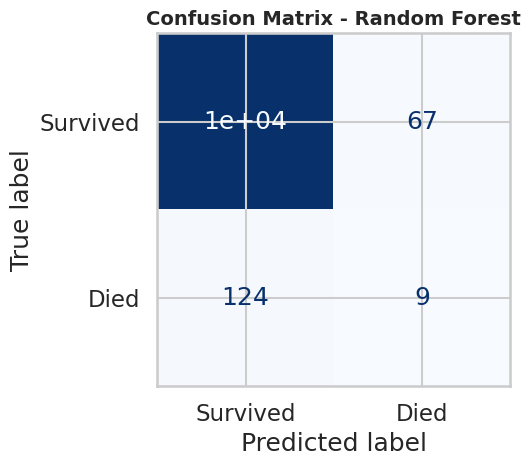


Confusion Matrix:
  True Negatives  (Survived → predicted Survived) : 10,272
  False Positives (Survived → predicted Died)     : 67
  False Negatives (Died → predicted Survived)     : 124
  True Positives  (Died → predicted Died)         : 9


In [11]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]   # probability of dying

# ── Classification Report ──
print("=" * 56)
print("          CLASSIFICATION REPORT")
print("=" * 56)
print(classification_report(y_test, y_pred, target_names=['Survived (0)', 'Died (1)']))

auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {auc:.4f}  (0.5 = random guessing, 1.0 = perfect)")

# ── Confusion Matrix ──
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=['Survived', 'Died']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix:")
print(f"  True Negatives  (Survived → predicted Survived) : {cm[0,0]:,}")
print(f"  False Positives (Survived → predicted Died)     : {cm[0,1]:,}")
print(f"  False Negatives (Died → predicted Survived)     : {cm[1,0]:,}")
print(f"  True Positives  (Died → predicted Died)         : {cm[1,1]:,}")

## Step 7 | Prediction Finding

In this part I wanted to show what actually predicts survival by looking at the Random Forest Scores. I tried to show how much it reduces prediction uncertanity across 200 trees.

At the end we come to the conclusion that higher score means the feature is more decisive.

Feature Importance Scores:
  GDP per Capita     0.4352  █████████████████████
  Age                0.2595  ████████████
  Peak Height        0.2241  ███████████
  Season             0.0432  ██
  Oxygen Used        0.0224  █
  Gender             0.0155  

→ Most important feature: 'GDP per Capita'


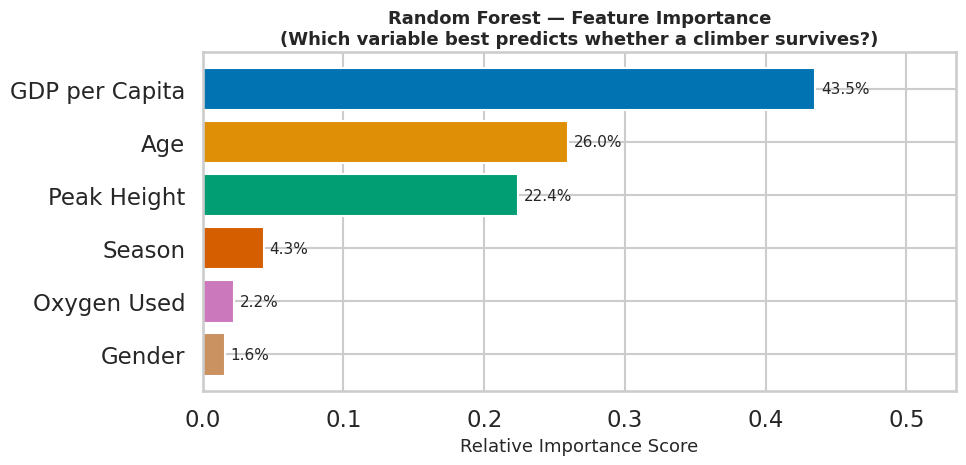

In [12]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=FEATURE_LABELS
).sort_values(ascending=False)

print("Feature Importance Scores:")
for feat, score in importances.items():
    bar = '█' * int(score * 50)
    print(f"  {feat:<18} {score:.4f}  {bar}")

print(f"\n→ Most important feature: '{importances.idxmax()}'")

fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette('colorblind', n_colors=len(importances))

bars = ax.barh(importances.index[::-1],
               importances.values[::-1],
               color=colors[::-1])

for bar, val in zip(bars, importances.values[::-1]):
    ax.text(bar.get_width() + 0.004,
            bar.get_y() + bar.get_height() / 2,
            f'{val*100:.1f}%', va='center', fontsize=11)

ax.set_xlabel('Relative Importance Score', fontsize=13)
ax.set_title('Random Forest — Feature Importance\n(Which variable best predicts whether a climber survives?)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, importances.max() + 0.10)
plt.tight_layout()
plt.show()

## Step 8 — Interpretation & Conclusion

### Feature Importance Results

Here are the results of the ML model we predicted:

| Rank | Feature | Score | Interpretation |
|---|---|---|---|
|  1st | **GDP per Capita** | ~44% | We found out that national wealth is the strongest predictor. As we found out in the Milestone 1 part of the project t-test (p < 0.00001); richer countries provide better training, equipment, and rescue infrastructure. We can say GDP affects survival in the most scenarios. |
|  2nd | **Age** | ~26% | Physical endurance gets weaker with age; extreme altitudes boosts this effect dramatically. |
|  3rd | **Peak Height** | ~22% | Higher mountains (Everest, K2, Lhotse) are objectively more deadly — thinner air, longer exposure, fewer rescue options etc ... |
| 4th | **Season** | ~4% | Winter expeditions are significantly more dangerous but it is a rare choice to look at; Spring is the standard "safe" season. |
| 5th | **Oxygen Used** | ~2% | Surprisingly oxgyen usage has stand alone importance. Oxygen use correlates with the hardest peaks, so peak height absorbs much of this variable in our ML predictions. |
| 6th | **Gender** | ~2% | Statistically gender was significant in Milestone 1 but in this part it has a small effect because male climbers are dominating the dataset (~95%),and limiting the signal. |

### Connection to Milestone 1

Both Milestones reach the **same conclusion**: Economic background (GDP per capita) is the strongest predictor of a climber's survival.

 The ML model adds:
- A **quantified ranking** of all variables, not just yes/no significance.
- Confirmed that **physical factors** (peak height, season) add meaningful predictive power on top of demographics.

The fatality rate is only ~1.3%, creating a severe class imbalance. Even with `class_weight='balanced'`, detecting the rare *Died* class remains hard. The ROC-AUC (~0.71) reflects genuine discriminative ability across probability thresholds, and is the appropriate metric for this problem.


Because only about 1.3% of climbers die, our data is heavily tilted to survivors. For that reason it is hard for the model to catch the fatalities because there is so few examples to learn from.

So we made our model using a special test called "ROC-AUC" and got a 0.71 (where 0.5 is random guessing and 1.0 is a perfect score). This score proves our model is actually finding real patterns to separate survivors from fatalities, rather than just making lucky guesses.